# Cryptarithms experiments

The encoder is in `cryptarithm.py`, the boolean structure in `formula.py`, the puzzle collection reader in `instances.py` and the main helper in `bench.py`. This notebook runs them and produces the tables and figures used in the report.

The brute force reference used for checking is defined in `test_cryptarithm.py` and takes no part in any measurement.

In [1]:
%load_ext autoreload
%autoreload 2

import platform
import sys

import pysat

print(sys.version)
print(platform.platform())
print(platform.processor())
print("python-sat", pysat.__version__)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Windows-10-10.0.26200-SP0
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
python-sat 1.9.dev7


## 1. Correctness against enumeration

Formulas small enough to try every assignment. The solver must find the same number of solutions in both uniqueness modes.

In [2]:
import pandas as pd

import formula as F
from cryptarithm import is_unique, parse, solve_formula
from test_cryptarithm import brute_force

def count(text, base=10, distinct=True, leading_zero=False):
    return solve_formula(F.parse(text), base, distinct, leading_zero, limit=None).count

cases = ["AB+BA=CD", "AB+BA=CDE", "TWO+TWO=FOUR", "A+B=CD", "AB-BA=CD",
         "A+BC=BC", "NOT AB+BA=CDE AND AB+BA=CD", "AB+BA=CD OR AB+BA=CDE"]

rows = []
for text in cases:
    for distinct in (True, False):
        want = len(brute_force(text, distinct=distinct))
        got = count(text, distinct=distinct)
        rows.append({"formula": text,
                     "one-to-one": distinct,
                     "solver": got, "enumeration": want, "agree": got == want})

df_small = pd.DataFrame(rows)
print("all agree:", bool(df_small.agree.all()))
df_small

all agree: True


,formula,one-to-one,solver,enumeration,agree
0,AB+BA=CD,True,0,0,True
1,AB+BA=CD,False,36,36,True
2,AB+BA=CDE,True,12,12,True
3,AB+BA=CDE,False,45,45,True
4,TWO+TWO=FOUR,True,7,7,True
5,TWO+TWO=FOUR,False,50,50,True
6,A+B=CD,True,30,30,True
7,A+B=CD,False,45,45,True
8,AB-BA=CD,True,21,21,True
9,AB-BA=CD,False,28,28,True


## 2. The base (k) is a parameter

The numbers are of base $k$, so the encoding must work for any $k$.

In [3]:
rows = []
for base in (5, 8, 10, 12, 16):
    for text in ("AB+BA=CD", "A+B=CD", "AB+BA=CDE"):
        want = len(brute_force(text, base=base))
        got = count(text, base=base)
        rows.append({"base": base, "formula": text,
                     "solver": got, "enumeration": want, "agree": got == want})

df_base = pd.DataFrame(rows)
print("all agree:", bool(df_base.agree.all()))
df_base.pivot_table(index="formula", columns="base", values="solver")

all agree: True


base,5,8,10,12,16
formula,,,,,
A+B=CD,4.0,16.0,30.0,48.0,96.0
AB+BA=CD,0.0,0.0,0.0,0.0,0.0
AB+BA=CDE,0.0,4.0,12.0,24.0,60.0


## 3. The two task options (1 to 1, repeats)

The one-to-one reading of characters has to be optional and leading zeros are forbidden for a word of more than one letter. A word of a single letter is its own leading digit and is allowed to be zero.

In [4]:
rows = []
for text in ("AB+BA=CD", "AB+BA=CDE", "TWO+TWO=FOUR"):
    rows.append({"formula": text,
                 "one-to-one": count(text, distinct=True),
                 "repeats allowed": count(text, distinct=False),
                 "leading zeros allowed": count(text, leading_zero=True)})

df_opts = pd.DataFrame(rows)
print("AB+BA equals 11(A+B), so a two digit result forces C=D,")
print("which the one-to-one rule forbids and the relaxed reading permits")
print()
sols = solve_formula(F.parse("A+BC=BC"), limit=None).solutions
print(f"A+BC=BC has {len(sols)} solutions, all with A=0: "
      f"{all(s.assignment['A'] == 0 for s in sols)}")
df_opts

AB+BA equals 11(A+B), so a two digit result forces C=D,
which the one-to-one rule forbids and the relaxed reading permits

A+BC=BC has 72 solutions, all with A=0: True


,formula,one-to-one,repeats allowed,leading zeros allowed
0,AB+BA=CD,0,36,0
1,AB+BA=CDE,12,45,12
2,TWO+TWO=FOUR,7,50,19


## 4. Compound formulas

Equations joined by `AND`, `OR` and `NOT`. All equations of a formula share one alphabet, so a letter means the same digit throughout. Each equation becomes a single variable that is true when the equation holds, which is what allows an equation to be negated.

In [5]:
x, y = "AB+BA=CD", "AB+BA=CDE"
compound = [x, y, f"{x} AND {y}", f"{x} OR {y}", f"NOT {x}", f"NOT {x} AND {y}",
            f"NOT ({x} OR {y})"]

rows = []
for text in compound:
    got, want = count(text), len(brute_force(text))
    rows.append({"formula": text, "solver": got,
                 "enumeration": want, "agree": got == want})

df_comp = pd.DataFrame(rows)
print("all agree:", bool(df_comp.agree.all()))
df_comp

all agree: True


,formula,solver,enumeration,agree
0,AB+BA=CD,0,0,True
1,AB+BA=CDE,12,12,True
2,AB+BA=CD AND AB+BA=CDE,0,0,True
3,AB+BA=CD OR AB+BA=CDE,12,12,True
4,NOT AB+BA=CD,3528,3528,True
5,NOT AB+BA=CD AND AB+BA=CDE,12,12,True
6,NOT (AB+BA=CD OR AB+BA=CDE),21156,21156,True


## 5. The puzzle collection

Every line of the collection carries a puzzle together with its solution, so the digit of each letter is known in advance and the files serve as ground truth rather than only as input.

In [6]:
from instances import BENCHMARK, families, load_all

puzzles = load_all()
df_inst = pd.DataFrame([{"source": p.source, "puzzle": p.text,
                         "addends": p.n_terms, "letters": len(p.letters),
                         "longest word": max(len(w) for w in p.words)}
                        for p in puzzles])

print(f"{len(families())} files, {len(df_inst)} puzzles")
print(f"addends {df_inst.addends.min()} to {df_inst.addends.max()}, "
      f"letters {df_inst.letters.min()} to {df_inst.letters.max()}")
print()
print(puzzles[0].text, "expects", puzzles[0].expected)
df_inst.groupby("source").agg(puzzles=("puzzle", "count"),
                              addends=("addends", "max"),
                              letters=("letters", "max"))

14 files, 1997 puzzles
addends 2 to 8, letters 4 to 10

COMET+SATURN=URANUS expects {'C': 6, 'O': 1, 'M': 0, 'E': 7, 'T': 8, 'S': 2, 'A': 9, 'U': 3, 'R': 5, 'N': 4}


,puzzles,addends,letters
source,,,
astro,80,3,10
city-jp,687,3,10
colors,28,3,10
computer,380,3,10
de-num,6,5,10
eg-num,45,7,10
es-num,50,8,10
fr-num,14,5,10
fruit,71,3,10


## 5b. Compound formulas built from the collection

More complex formulas which use these equations are also tested, applying the connectives to real puzzles. Two puzzles can only be joined while the letters they use together still fit the base, so the pairs are taken from puzzles that draw on the same alphabet.

Since both equations share that alphabet, a conjunction should give the intersection of the two solution sets and a disjunction their union. The two sides cannot be compared directly, though. Forbidding a leading zero applies to every word in the formula, and a letter that stands alone in one equation may begin a word in the other, so a compound formula constrains words that neither equation constrains on its own.

An extra step is therefore needed. The first letters of the words of both equations are collected, and any solution found for one equation alone which gives one of them the digit zero is discarded before the union or the intersection is taken.

In [7]:
import collections
import random
import time
from itertools import combinations

def sols(text):
    r = solve_formula(F.parse(text), limit=None)
    return {tuple(sorted(s.assignment.items())) for s in r.solutions}

def leading(text):
    return {w[0] for e in F.equations(F.parse(text)) for w in e.words if len(w) > 1}

def keep(S, lead):
    return {s for s in S if all(v != 0 for c, v in s if c in lead)}

by_alphabet = collections.defaultdict(list)
for p in puzzles:
    by_alphabet[frozenset(p.letters)].append(p)

pairs = [(a, b) for ls, g in by_alphabet.items() if len(ls) <= 10 and len(g) >= 2
         for a, b in combinations(g[:4], 2)]
print(f"puzzle pairs over one alphabet available: {len(pairs)}")

rng = random.Random(3)
sample = rng.sample(pairs, 40)

rows = []
t0 = time.perf_counter()
for a, b in sample:
    lead = leading(a.text) | leading(b.text)
    SA, SB = keep(sols(a.text), lead), keep(sols(b.text), lead)
    for op, want in [("AND", SA & SB), ("OR", SA | SB), ("AND NOT", SA - SB)]:
        text = f"{a.text} {op} {b.text}" if op != "AND NOT" else f"{a.text} AND NOT {b.text}"
        got = sols(text)
        rows.append({"left": a.text, "right": b.text, "connective": op,
                     "solutions": len(got), "expected": len(want), "agree": got == want})

df_pairs = pd.DataFrame(rows)
print(f"{len(sample)} pairs, {len(df_pairs)} compound formulas "
      f"in {time.perf_counter()-t0:.1f}s")
print(f"agree with the set algebra: {int(df_pairs.agree.sum())} of {len(df_pairs)}")
print()
print(df_pairs.groupby("connective").agg(formulas=("agree", "count"),
                                         agree=("agree", "sum"),
                                         solutions=("solutions", "sum")).to_string())
print()
df_pairs.head(9)

puzzle pairs over one alphabet available: 1007

40 pairs, 120 compound formulas in 11.6s
agree with the set algebra: 120 of 120

            formulas  agree  solutions
connective                            
AND               40     40          0
AND NOT           40     40         37
OR                40     40         77



,left,right,connective,solutions,expected,agree
0,AKITA+NARA+NIKKO=TOYAMA,AOMORI+NARA+TOKYO=TOYAMA,AND,0,0,True
1,AKITA+NARA+NIKKO=TOYAMA,AOMORI+NARA+TOKYO=TOYAMA,OR,2,2,True
2,AKITA+NARA+NIKKO=TOYAMA,AOMORI+NARA+TOKYO=TOYAMA,AND NOT,1,1,True
3,FILE+FOLDER+MODEM=MEMORY,FILE+MEMORY+ROM=FOLDER,AND,0,0,True
4,FILE+FOLDER+MODEM=MEMORY,FILE+MEMORY+ROM=FOLDER,OR,2,2,True
5,FILE+FOLDER+MODEM=MEMORY,FILE+MEMORY+ROM=FOLDER,AND NOT,1,1,True
6,CRACK+REBOOT+WWW=HACKER,ERROR+HACKER+WEB=REBOOT,AND,0,0,True
7,CRACK+REBOOT+WWW=HACKER,ERROR+HACKER+WEB=REBOOT,OR,2,2,True
8,CRACK+REBOOT+WWW=HACKER,ERROR+HACKER+WEB=REBOOT,AND NOT,1,1,True


## 6. The sweep

Every puzzle of the collection, enumerating all solutions so that both the assignment and the number of solutions can be checked.

In [8]:
import time

from bench import sweep, to_records

t0 = time.perf_counter()
rows = sweep(puzzles, mode="all")
elapsed = time.perf_counter() - t0

df = pd.DataFrame(to_records(rows))
df.to_csv("results.csv", index=False)

print(f"{len(df)} puzzles in {elapsed:.1f}s, errors: {int(df.error.notna().sum())}")
df.head(8)

1997 puzzles in 51.7s, errors: 0


,source,puzzle,n_terms,n_letters,longest_word,base,distinct,mode,solver,n_vars,n_clauses,solutions,calls,unique,matches_published,encode_time,solve_time,error,total_time
0,astro,COMET+SATURN=URANUS,2,10,6,10,True,all,cadical153,1079,3280,1,2,True,True,0.000844,0.012291,None,0.013135
1,astro,COMET+URANUS=SATURN,2,10,6,10,True,all,cadical153,1079,3280,1,2,True,True,0.000652,0.022541,None,0.023192
2,astro,EARTH+PHOBOS=EUROPA,2,10,6,10,True,all,cadical153,1079,3280,1,2,True,True,0.000745,0.030415,None,0.031160
3,astro,EARTH+SATURN=TRITON,2,10,6,10,True,all,cadical153,1079,3280,1,2,True,True,0.000656,0.010600,None,0.011256
4,astro,EARTH+URANUS=SATURN,2,8,6,10,True,all,cadical153,1041,3056,1,2,True,True,0.000614,0.007433,None,0.008048
5,astro,EUROPA+JUPITER=NEPTUNE,2,10,7,10,True,all,cadical153,1229,3731,1,2,True,True,0.000727,0.016748,None,0.017475
6,astro,EUROPA+PLANETS=NEPTUNE,2,10,7,10,True,all,cadical153,1229,3731,1,2,True,True,0.000740,0.007805,None,0.008544
7,astro,EUROPA+SATURN=URANUS,2,9,6,10,True,all,cadical153,1109,3368,1,2,True,True,0.000674,0.017492,None,0.018167


## 7. The published solutions are found

The digits printed in the collection must be among the solutions the solver reports.

In [9]:
ok = df[df.error.isna()]
print(f"puzzles solved            : {len(ok)}")
print(f"at least one solution     : {int((ok.solutions > 0).sum())}")
print(f"published assignment found: {int(ok.matches_published.sum())}")
print(f"reported as unique        : {int(ok.unique.sum())}")
print()
mismatch = ok[~ok.matches_published.astype(bool)]
print(f"puzzles where the published assignment was not found: {len(mismatch)}")
mismatch[["source", "puzzle", "solutions"]]

puzzles solved            : 1997
at least one solution     : 1997
published assignment found: 1997
reported as unique        : 1997

puzzles where the published assignment was not found: 0


,source,puzzle,solutions


## 8. Uniqueness

The collection was generated by searching for puzzles with a single solution, so every one of them should be reported as unique. For deciding uniqueness finding two solutions is sufficient.

In [10]:
t0 = time.perf_counter()
rows_u = sweep(puzzles, mode="unique")
unique_elapsed = time.perf_counter() - t0
df_u = pd.DataFrame(to_records(rows_u))

agree = (df_u.unique.fillna(False).astype(bool)
         == ok.set_index(df_u.index).unique.fillna(False).astype(bool))
print(f"deciding uniqueness  : {unique_elapsed:.1f}s over {len(df_u)} puzzles")
print(f"enumerating all      : {elapsed:.1f}s")
print(f"reported unique      : {int(df_u.unique.fillna(False).sum())} of {len(df_u)}")
print(f"agrees with the full enumeration: {bool(agree.all())}")
print()
print()
print("Every puzzle in the collection has one solution, so the limit of two")
print("models is never reached and both modes do the same work: one call for")
print("the model, a blocking clause, then one call that comes back unsat.")
print("The difference in wall clock below is run to run noise, not a saving.")
print()
print("solver calls, one call per solution plus one to prove there are no more")
pd.DataFrame({"enumerate all": df.groupby("mode").calls.mean(),
              "decide uniqueness": df_u.groupby("mode").calls.mean()}).round(2)

deciding uniqueness  : 52.4s over 1997 puzzles
enumerating all      : 51.7s
reported unique      : 1997 of 1997
agrees with the full enumeration: True


Every puzzle in the collection has one solution, so the limit of two
models is never reached and both modes do the same work: one call for
the model, a blocking clause, then one call that comes back unsat.
The difference in wall clock below is run to run noise, not a saving.

solver calls, one call per solution plus one to prove there are no more


,enumerate all,decide uniqueness
mode,,
all,2.0,NaN
unique,NaN,2.0


## 9. Size of the encoding and cost

The encoding grows with the number of addends, since every addend contributes a column term to the running sum, and with the length of the longest word, which fixes the number of columns.

In [11]:
by_terms = ok.groupby("n_terms").agg(
    puzzles=("puzzle", "count"),
    letters=("n_letters", "mean"),
    variables=("n_vars", "mean"),
    clauses=("n_clauses", "mean"),
    encode_s=("encode_time", "mean"),
    solve_s=("solve_time", "mean"),
    total_s=("total_time", "mean"),
).round(4)
by_terms

,puzzles,letters,variables,clauses,encode_s,solve_s,total_s
n_terms,,,,,,,
2,215,9.0791,1052.5395,3145.7395,0.0010,0.0083,0.0093
3,1644,9.5182,1339.1356,4553.8729,0.0020,0.0198,0.0219
4,34,9.2941,1753.5882,6680.7941,0.0031,0.0250,0.0281
5,95,9.4632,2196.6947,9107.9263,0.0044,0.0468,0.0511
6,3,10.0000,3140.3333,13977.3333,0.0112,0.0973,0.1086
7,4,10.0000,3520.2500,16388.5000,0.0032,0.2244,0.2276
8,2,10.0000,4070.0000,19468.5000,0.0171,0.2236,0.2407


In [12]:
by_source = ok.groupby("source").agg(
    puzzles=("puzzle", "count"),
    addends=("n_terms", "max"),
    letters=("n_letters", "max"),
    clauses=("n_clauses", "mean"),
    total_s=("total_time", "mean"),
    slowest_s=("total_time", "max"),
).round(4)
print(f"total solving time over the whole collection: {ok.total_time.sum():.1f}s")
by_source

total solving time over the whole collection: 45.5s


,puzzles,addends,letters,clauses,total_s,slowest_s
source,,,,,,
astro,80,3,10,4380.4625,0.0293,0.1013
city-jp,687,3,10,4851.5066,0.0179,0.1625
colors,28,3,10,4394.7500,0.0418,0.1183
computer,380,3,10,3980.3053,0.0192,0.1474
de-num,6,5,10,8047.0000,0.0230,0.0543
eg-num,45,7,10,8742.8000,0.0493,0.3034
es-num,50,8,10,9370.2800,0.0479,0.3012
fr-num,14,5,10,7747.7857,0.0684,0.3244
fruit,71,3,10,4317.8592,0.0405,0.1498


## 10. The instance given by the task page

An equation with 41 addends and 10 distinct letters, so in base ten under the one-to-one requirement every digit is used once.

In [13]:
eq = parse(BENCHMARK)
print(f"addends {len(eq.terms)}, distinct words {len(set(w for _, w in eq.terms))}, "
      f"letters {len(eq.letters)} {''.join(sorted(eq.letters))}")

# wall clock on this instance varies by a factor of two between runs, so each
# mode is repeated and the median is reported
REPEATS = 5
bench_rows = []
for mode in ("first", "unique", "all"):
    limit = {"first": 1, "unique": 2, "all": None}[mode]
    runs = [solve_formula(F.parse(BENCHMARK), limit=limit) for _ in range(REPEATS)]
    enc = sorted(x.encode_time for x in runs)
    sol = sorted(x.solve_time for x in runs)
    tot = sorted(x.encode_time + x.solve_time for x in runs)
    mid = REPEATS // 2
    r = runs[0]
    bench_rows.append({"mode": mode, "variables": r.n_vars, "clauses": r.n_clauses,
                       "solutions": r.count, "calls": r.calls,
                       "encode_s": round(enc[mid], 3),
                       "solve_s": round(sol[mid], 3),
                       "total_s": round(tot[mid], 3),
                       "solve_min": round(sol[0], 3),
                       "solve_max": round(sol[-1], 3)})

df_bench = pd.DataFrame(bench_rows)

r = solve_formula(F.parse(BENCHMARK), limit=1)
a = r.solutions[0].assignment
value = lambda w: int("".join(str(a[c]) for c in w))
lhs = sum(sign * value(w) for sign, w in eq.terms)
print(f"solution {a}")
print(f"sum of the addends {lhs}, TESTS {value(eq.result)}, equal {lhs == value(eq.result)}")
print(f"letters distinct {len(set(a.values())) == len(a)}, digits used {sorted(a.values())}")
print(f"median of {REPEATS} runs per mode")
df_bench


addends 41, distinct words 31, letters 10 AEHMNORSTY


solution {'S': 3, 'O': 1, 'M': 2, 'A': 7, 'N': 6, 'Y': 4, 'R': 8, 'E': 0, 'T': 9, 'H': 5}
sum of the addends 90393, TESTS 90393, equal True
letters distinct True, digits used [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
median of 5 runs per mode


,mode,variables,clauses,solutions,calls,encode_s,solve_s,total_s,solve_min,solve_max
0,first,48480,297651,1,1,0.214,3.377,3.591,3.288,3.464
1,unique,48480,297651,1,2,0.198,4.866,5.079,4.652,4.996
2,all,48480,297651,1,2,0.205,5.018,5.221,4.578,5.084


## 11. Figures

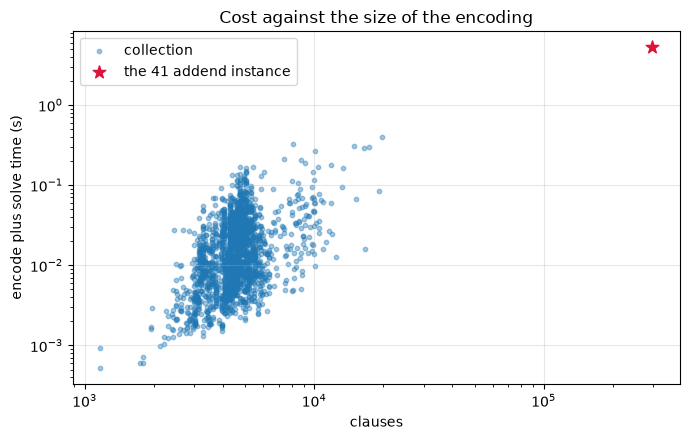

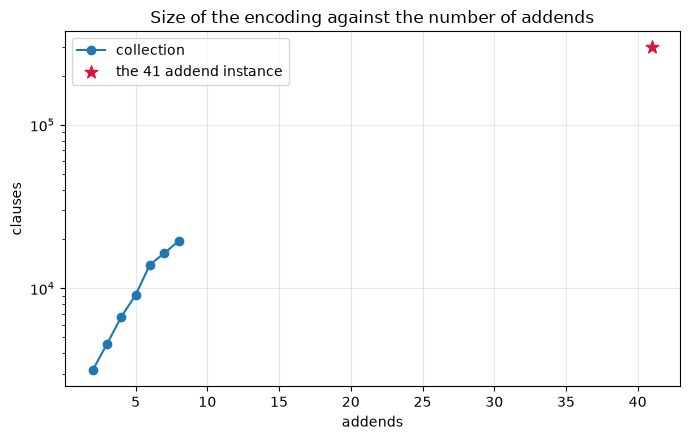

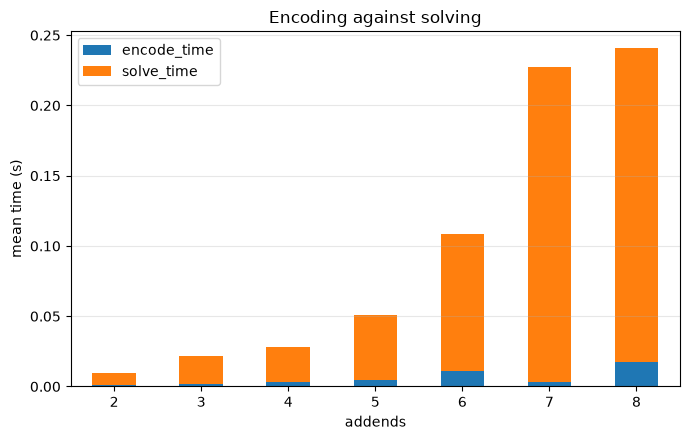

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt

figdir = Path("../report/figures")
figdir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(ok.n_clauses, ok.total_time, s=10, alpha=0.4, label="collection")
b = df_bench[df_bench["mode"] == "all"].iloc[0]
ax.scatter([b.clauses], [b.total_s], s=90, marker="*", color="crimson",
           label="the 41 addend instance")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("clauses")
ax.set_ylabel("encode plus solve time (s)")
ax.set_title("Cost against the size of the encoding")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(figdir / "time_vs_clauses.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
grouped = ok.groupby("n_terms").n_clauses.mean()
ax.plot(grouped.index, grouped.values, marker="o", label="collection")
ax.scatter([41], [b.clauses], s=90, marker="*", color="crimson",
           label="the 41 addend instance")
ax.set_yscale("log")
ax.set_xlabel("addends")
ax.set_ylabel("clauses")
ax.set_title("Size of the encoding against the number of addends")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(figdir / "clauses_vs_addends.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
phases = ok.groupby("n_terms")[["encode_time", "solve_time"]].mean()
phases.plot(kind="bar", stacked=True, ax=ax)
ax.set_xlabel("addends")
ax.set_ylabel("mean time (s)")
ax.set_title("Encoding against solving")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(figdir / "phases.pdf")
plt.show()